In [1]:
import pathlib
import tarfile
import yaml

import numpy as np
import pandas as pd

import scipy.stats
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from plot_utils import annotate_ax_with_correlations as annotate_facet_with_correlations

In [2]:
!ls /mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/screening_data_nstruct_1000/ | wc -l

ls: cannot access '/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/screening_data_nstruct_1000/': Permission denied
0


In [3]:
def load_results_from_directory(load_dir):
    results = {}
    for filename in pathlib.Path(load_dir).glob("*.tar.gz"):
        try:
            with tarfile.open(filename, "r:gz") as tar:
                with tar.extractfile("./info.yaml") as fh:
                    ret = yaml.safe_load(fh)
                    results[ret["variant"]] = {
                        'parent':filename.name.split("_")[0],
                        'interface_delta_X':ret["results"]["best_struct_interface_delta_X"],
                        'total_energy':ret["results"]["best_struct_total_energy"]
                                         }
        except: # ignore all errors
            raise
            print(f"Error with reading {filename}")
    results_df = pd.DataFrame.from_dict(results, orient="index")
    return results_df

In [4]:
#!rm $save_filename

In [5]:
load_dir = f"/mnt/rdrive/promero2/General/Sameer/SadA_azidation/rosetta/screening_data_nstruct_1000"
save_filename = f"../data/rosetta/screening_data_nstruct_1000.csv"
if not pathlib.Path(save_filename).exists():
    results_df = load_results_from_directory(load_dir)
    results_df.to_csv(save_filename, index=True, index_label="variant")
rep_1_df = pd.read_csv(save_filename)

In [6]:
rep_1_df

,variant,parent,interface_delta_X,total_energy
0,F62S.G79S.L107P.F150S.L152P,2L,-16.956,-851.950
1,Q236R.L237Q,1VH,-13.841,-867.424
2,D121E.P149Q,2L,-13.470,-870.115
3,A50V.T265S,3VRL,-13.088,-867.226
4,H155Y.H264R,2L,-14.034,-866.108
...,...,...,...,...
1233,E19G.Q85L.L107P.M193V.L237Q.K243R.E266G,1VH,-13.237,-861.017
1234,L81P.L115P.P149A.A225V,2L,-12.654,-851.488
1235,H68R.Q233L,1VH,-13.814,-873.920
1236,I23V.T77A.L78Q,2L,-15.053,-861.025


In [7]:
final_seqs = pd.read_csv("../rosetta/screening_data/ordinal_Oct22_sequences_as_variant.csv")

In [8]:
final_dca = pd.read_csv("../output/ordinal_Oct22_sequences_with_dca_score.csv")

In [9]:
final_seqs

,parent,variant,sequence_aa_trim
0,1VH,A15S.F152L.N198K,QHTYPAQLMRFGTSARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
1,1VH,K227E,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
2,1VH,P6R.S60G.G86D,QHTYRAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
3,1VH,A24V.N189D,QHTYPAQLMRFGTAARAEHMTIVAAIHALDADEADAIVMDIVPDGE...
4,1VH,T110S.M258I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
...,...,...,...
1321,3VRL,I219T.T238I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...
1322,3VRL,D41E.K88I.D164V,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMEIVPDGE...
1323,1VH,X1M,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
1324,2L,X1M,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...


In [10]:
df = pd.merge(final_seqs, rep_1_df)

In [11]:
df_noparent = df[df.variant.str.get(0) != 'X']

In [12]:
df_all = pd.merge(df_noparent, final_dca)
df_all["category"] = pd.Categorical(df_all.category, ["H", "P", "L", "N"])
df_all["response"] = df_all.category.astype(str).map({"H":3, "P":2, "L":1, "N":0})
df_all["aa_dist"] = df_all.variant.str.count("\.") + 1
df_all

,parent,variant,sequence_aa_trim,interface_delta_X,total_energy,category,response,dca_score,aa_dist
0,1VH,A15S.F152L.N198K,QHTYPAQLMRFGTSARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,-14.865,-868.411,H,3,-452.732642,3
1,1VH,P6R.S60G.G86D,QHTYRAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,-14.596,-875.364,H,3,-452.655719,3
2,1VH,A24V.N189D,QHTYPAQLMRFGTAARAEHMTIVAAIHALDADEADAIVMDIVPDGE...,-14.062,-877.270,P,2,-450.446437,2
3,1VH,T110S.M258I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,-14.236,-877.260,L,1,-452.323484,2
4,1VH,D36V,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEAVAIVMDIVPDGE...,-16.329,-869.965,L,1,-452.995313,1
...,...,...,...,...,...,...,...,...,...
1277,3VRL,K88I.D164V,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,-14.309,-859.395,N,0,-443.503933,2
1278,3VRL,G128C,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,-13.343,-869.892,N,0,-444.455052,1
1279,3VRL,H67L.I184T,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,-14.212,-866.162,N,0,-444.476726,2
1280,3VRL,I219T.T238I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,-13.627,-871.377,N,0,-446.797518,2


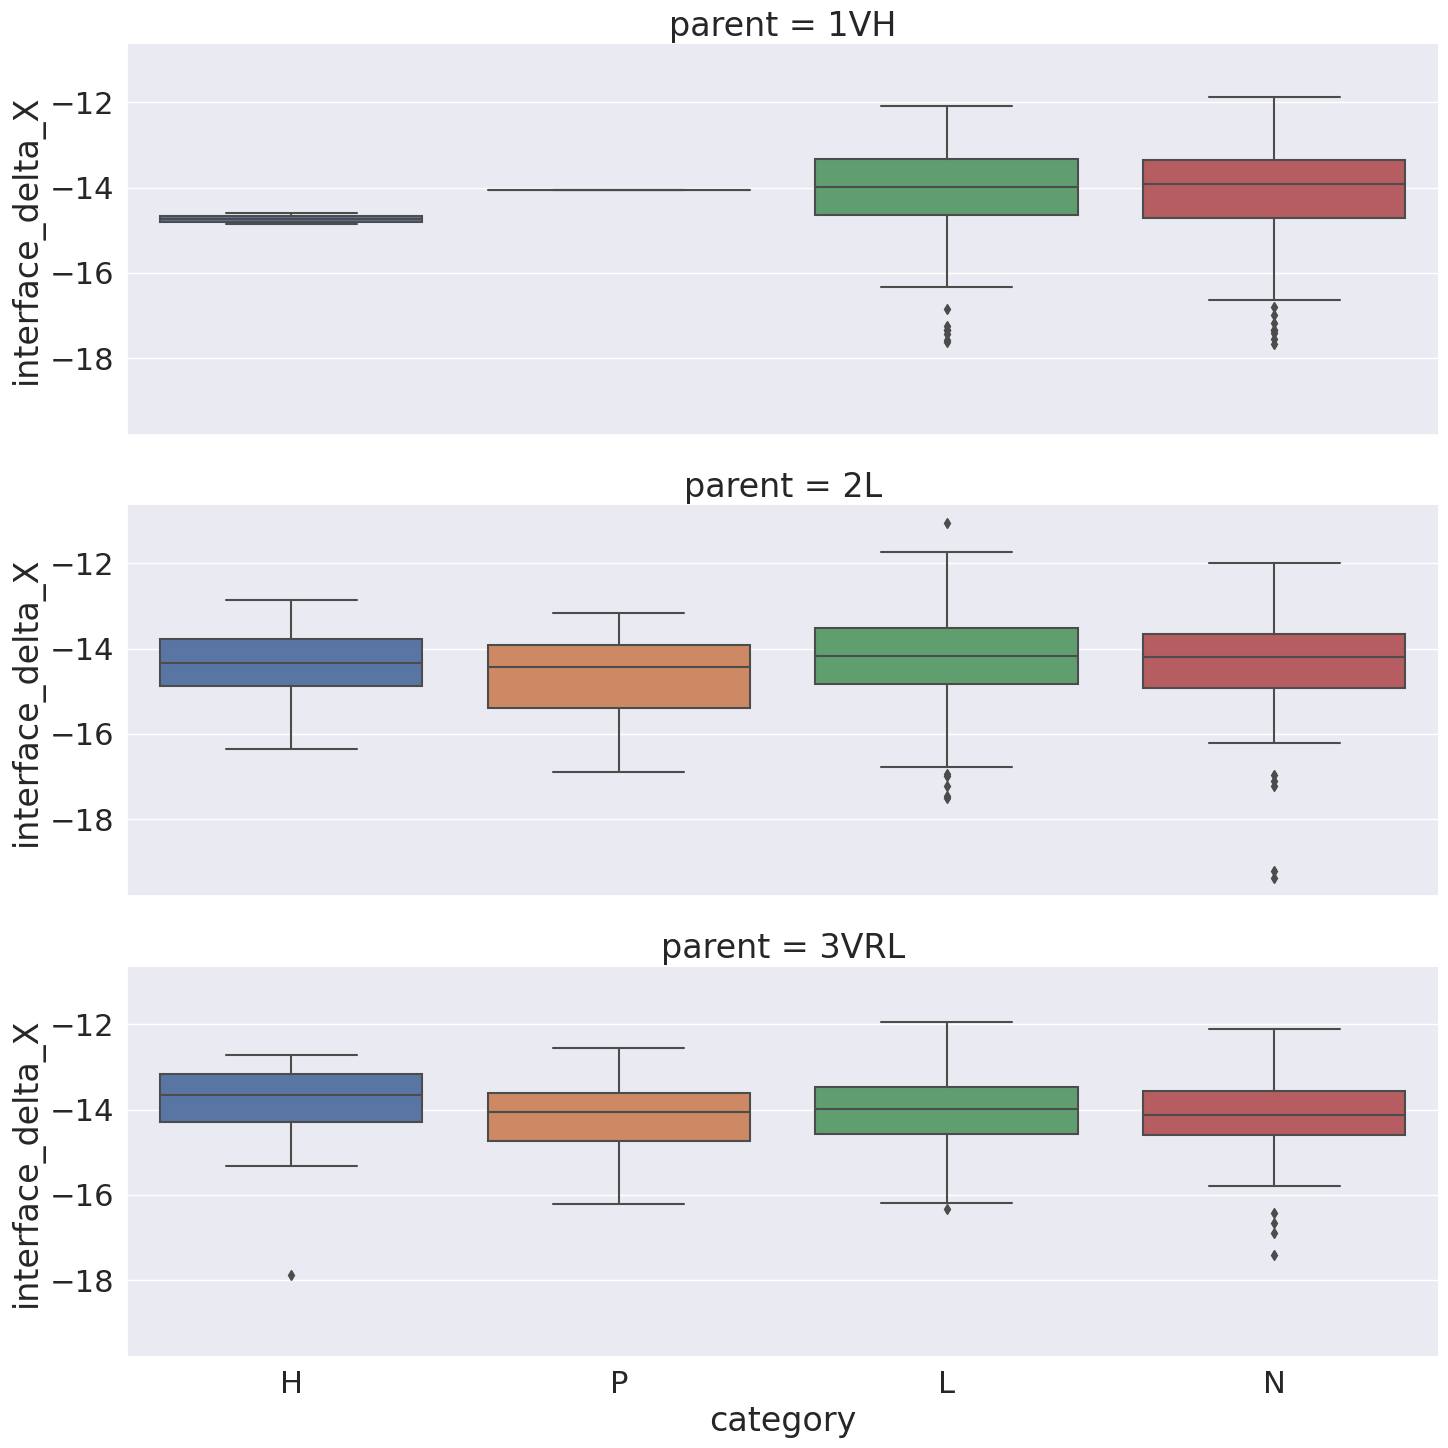

In [13]:
sns.set(font_scale = 2)

g = sns.catplot(x='category', y='interface_delta_X', row="parent", data=df_all, kind="box", aspect=3)
g.fig.savefig("../output/interface_delta_X_score_on_screening_data.png", dpi=300)


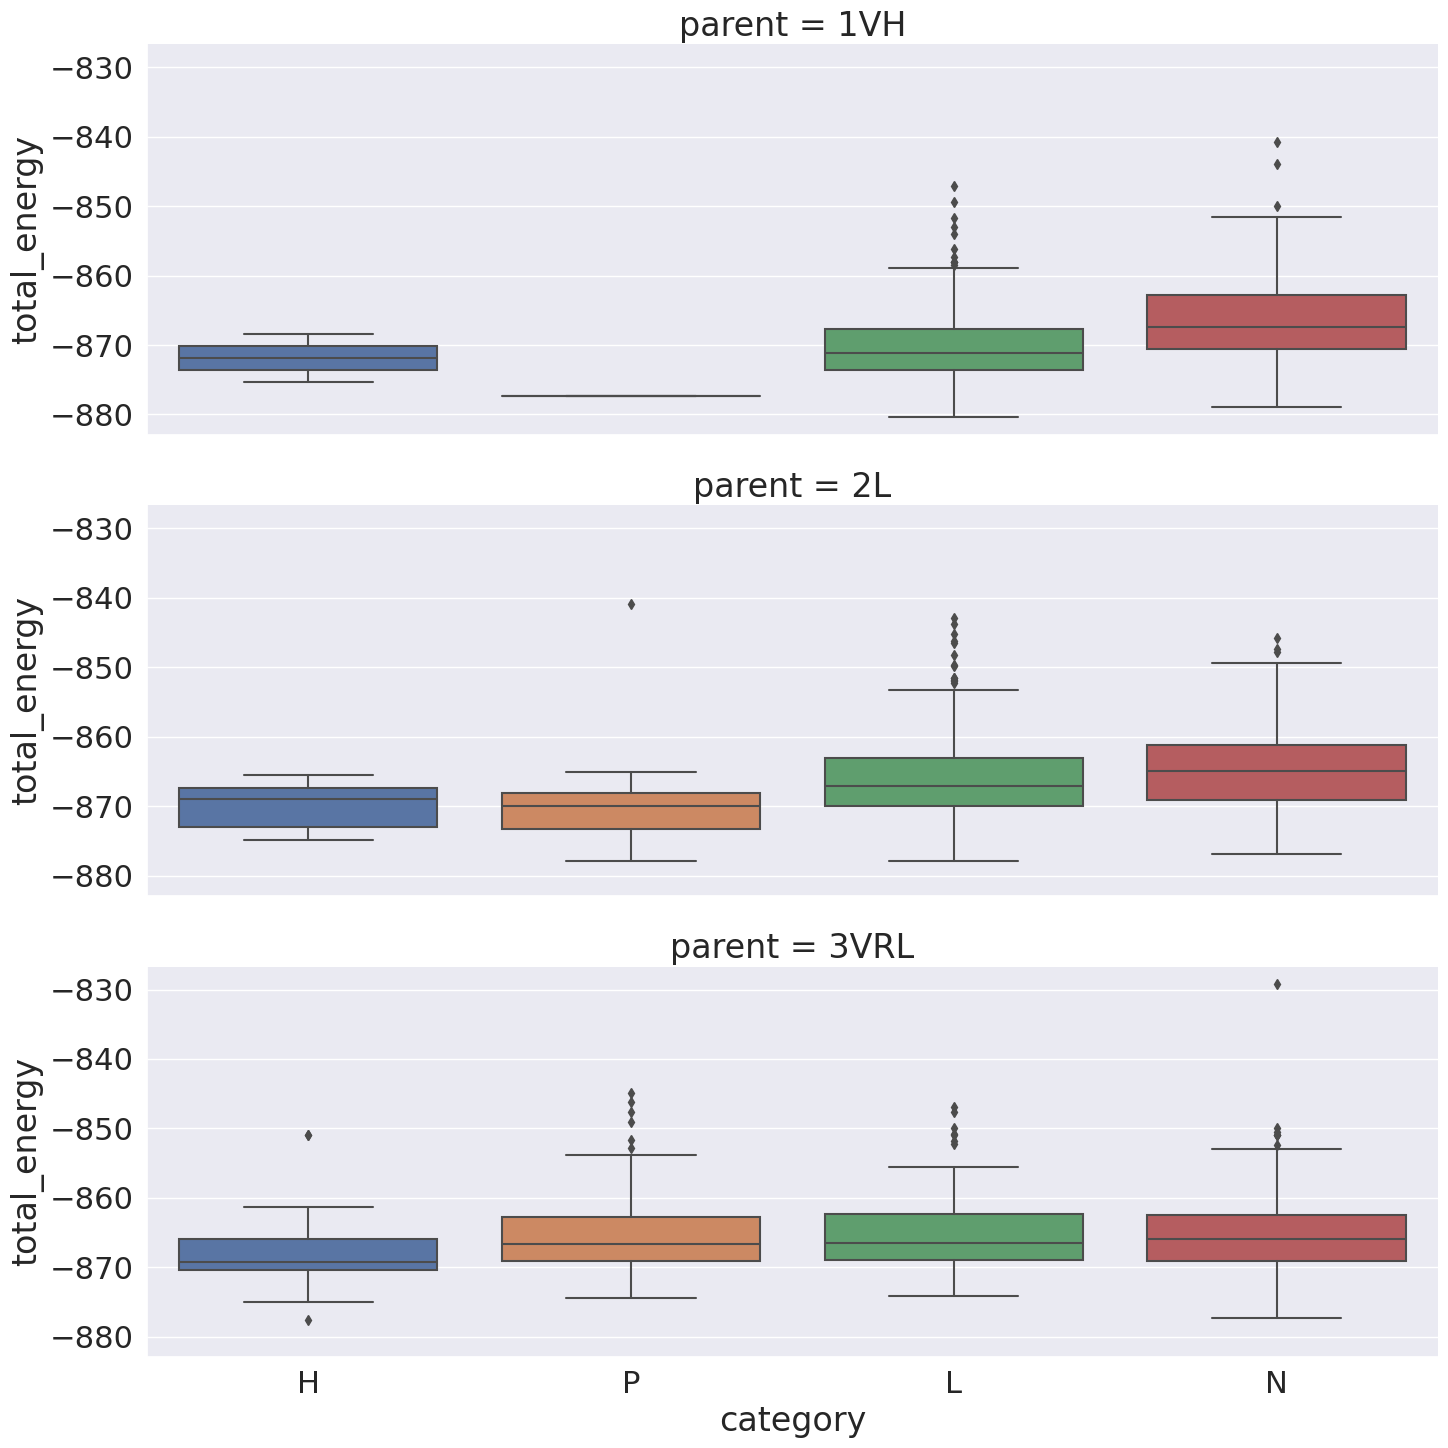

In [14]:
sns.set(font_scale = 2)
g = sns.catplot(x='category', y='total_energy', row="parent", data=df_all, kind="box", aspect=3)
g.fig.savefig("../output/ligand_dock_score_on_screening_data.png", dpi=300)


In [15]:
def f(x):
    d = {}

    sr = scipy.stats.spearmanr(-x.response, x.interface_delta_X)
    d['interface_delta_X_spearman'] = sr.statistic
    d['interface_delta_X_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.interface_delta_X)
    d['interface_delta_X_kendalltau'] = sk.statistic
    d['interface_delta_X_kendalltau_p'] = sr.pvalue

    sr = scipy.stats.spearmanr(-x.response, x.total_energy)
    d['total_energy_spearman'] = sr.statistic
    d['total_energy_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.total_energy)
    d['total_energy_kendalltau'] = sk.statistic
    d['total_energy_kendalltau_p'] = sr.pvalue
    
    sr = scipy.stats.spearmanr(-x.response, x.dca_score)
    d['dca_score_spearman'] = sr.statistic
    d['dca_score_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.total_energy)
    d['dca_score_kendalltau'] = sk.statistic
    d['dca_score_kendalltau_p'] = sr.pvalue
    
    

    d['N'] = len(x)
    return pd.Series(d, index=['interface_delta_X_spearman', 'interface_delta_X_spearman_p', 
                               'interface_delta_X_kendalltau', 'interface_delta_X_kendalltau_p', 
                               'total_energy_spearman', 'total_energy_spearman_p', 
                               'total_energy_kendalltau', 'total_energy_kendalltau_p',  
                               'dca_score_spearman', 'dca_score_spearman_p', 
                               'dca_score_kendalltau', 'dca_score_kendalltau_p',
                               'N'])


parent_aa_dist_stats = df_all.groupby(["parent", "aa_dist"]).apply(f)
parent_aa_dist_stats

interface_delta_X_spearman  interface_delta_X_spearman_p  \
parent aa_dist                                                             
1VH    1                          0.112907                      0.286609   
       2                         -0.116344                      0.230492   
       3                          0.152264                      0.138610   
       4                          0.083554                      0.555927   
       5                          0.015907                      0.925551   
       6                         -0.400892                      0.174601   
       7                          0.258199                      0.741801   
2L     1                          0.041046                      0.673187   
       2                          0.034867                      0.681466   
       3                          0.093660                      0.356477   
       4                         -0.135385                      0.306603   
       5                         -0.154129                      0.362396   
       6                          0.057735                      0.866102   
       7                               NaN                           NaN   
3VRL   1                          0.018405                      0.829731   
       2                         -0.095585                      0.254439   
       3                          0.017001                      0.881015   
       4                          0.049027                      0.773225   
       5                         -0.602094                      0.022706   
       6                         -0.292770                      0.573392   
       7                               NaN                           NaN   
       8                               NaN                           NaN   

                interface_delta_X_kendalltau  interface_delta_X_kendalltau_p  \
parent aa_dist                                                                 
1VH    1                            0.092833                        0.286609   
       2                           -0.095950                        0.230492   
       3                            0.123259                        0.138610   
       4                            0.069041                        0.555927   
       5                            0.013162                        0.925551   
       6                           -0.339683                        0.174601   
       7                            0.235702                        0.741801   
2L     1                            0.033841                        0.673187   
       2                            0.027881                        0.681466   
       3                            0.074676                        0.356477   
       4                           -0.111567                        0.306603   
       5                           -0.126221                        0.362396   
       6                            0.049237                        0.866102   
       7                                 NaN                             NaN   
3VRL   1                            0.015181                        0.829731   
       2                           -0.069366                        0.254439   
       3                            0.014337                        0.881015   
       4                            0.043743                        0.773225   
       5                           -0.496611                        0.022706   
       6                           -0.258199                        0.573392   
       7                                 NaN                             NaN   
       8                                 NaN                             NaN   

                total_energy_spearman  total_energy_spearman_p  \
parent aa_dist                                                   
1VH    1                     0.243669                 0.019938   
       2                     0.264050                 0.005756   
      

In [16]:
stats_to_plot = parent_aa_dist_stats[parent_aa_dist_stats.N > 50][[
    "interface_delta_X_spearman", "interface_delta_X_spearman_p",
    "total_energy_spearman", "total_energy_spearman_p",
   "dca_score_spearman", "dca_score_spearman_p"]]
stats_to_plot_melt = pd.melt(stats_to_plot.reset_index(), id_vars = ["parent", "aa_dist"])
stats_to_plot_melt.head()

,parent,aa_dist,variable,value
0,1VH,1,interface_delta_X_spearman,0.112907
1,1VH,2,interface_delta_X_spearman,-0.116344
2,1VH,3,interface_delta_X_spearman,0.152264
3,1VH,4,interface_delta_X_spearman,0.083554
4,2L,1,interface_delta_X_spearman,0.041046


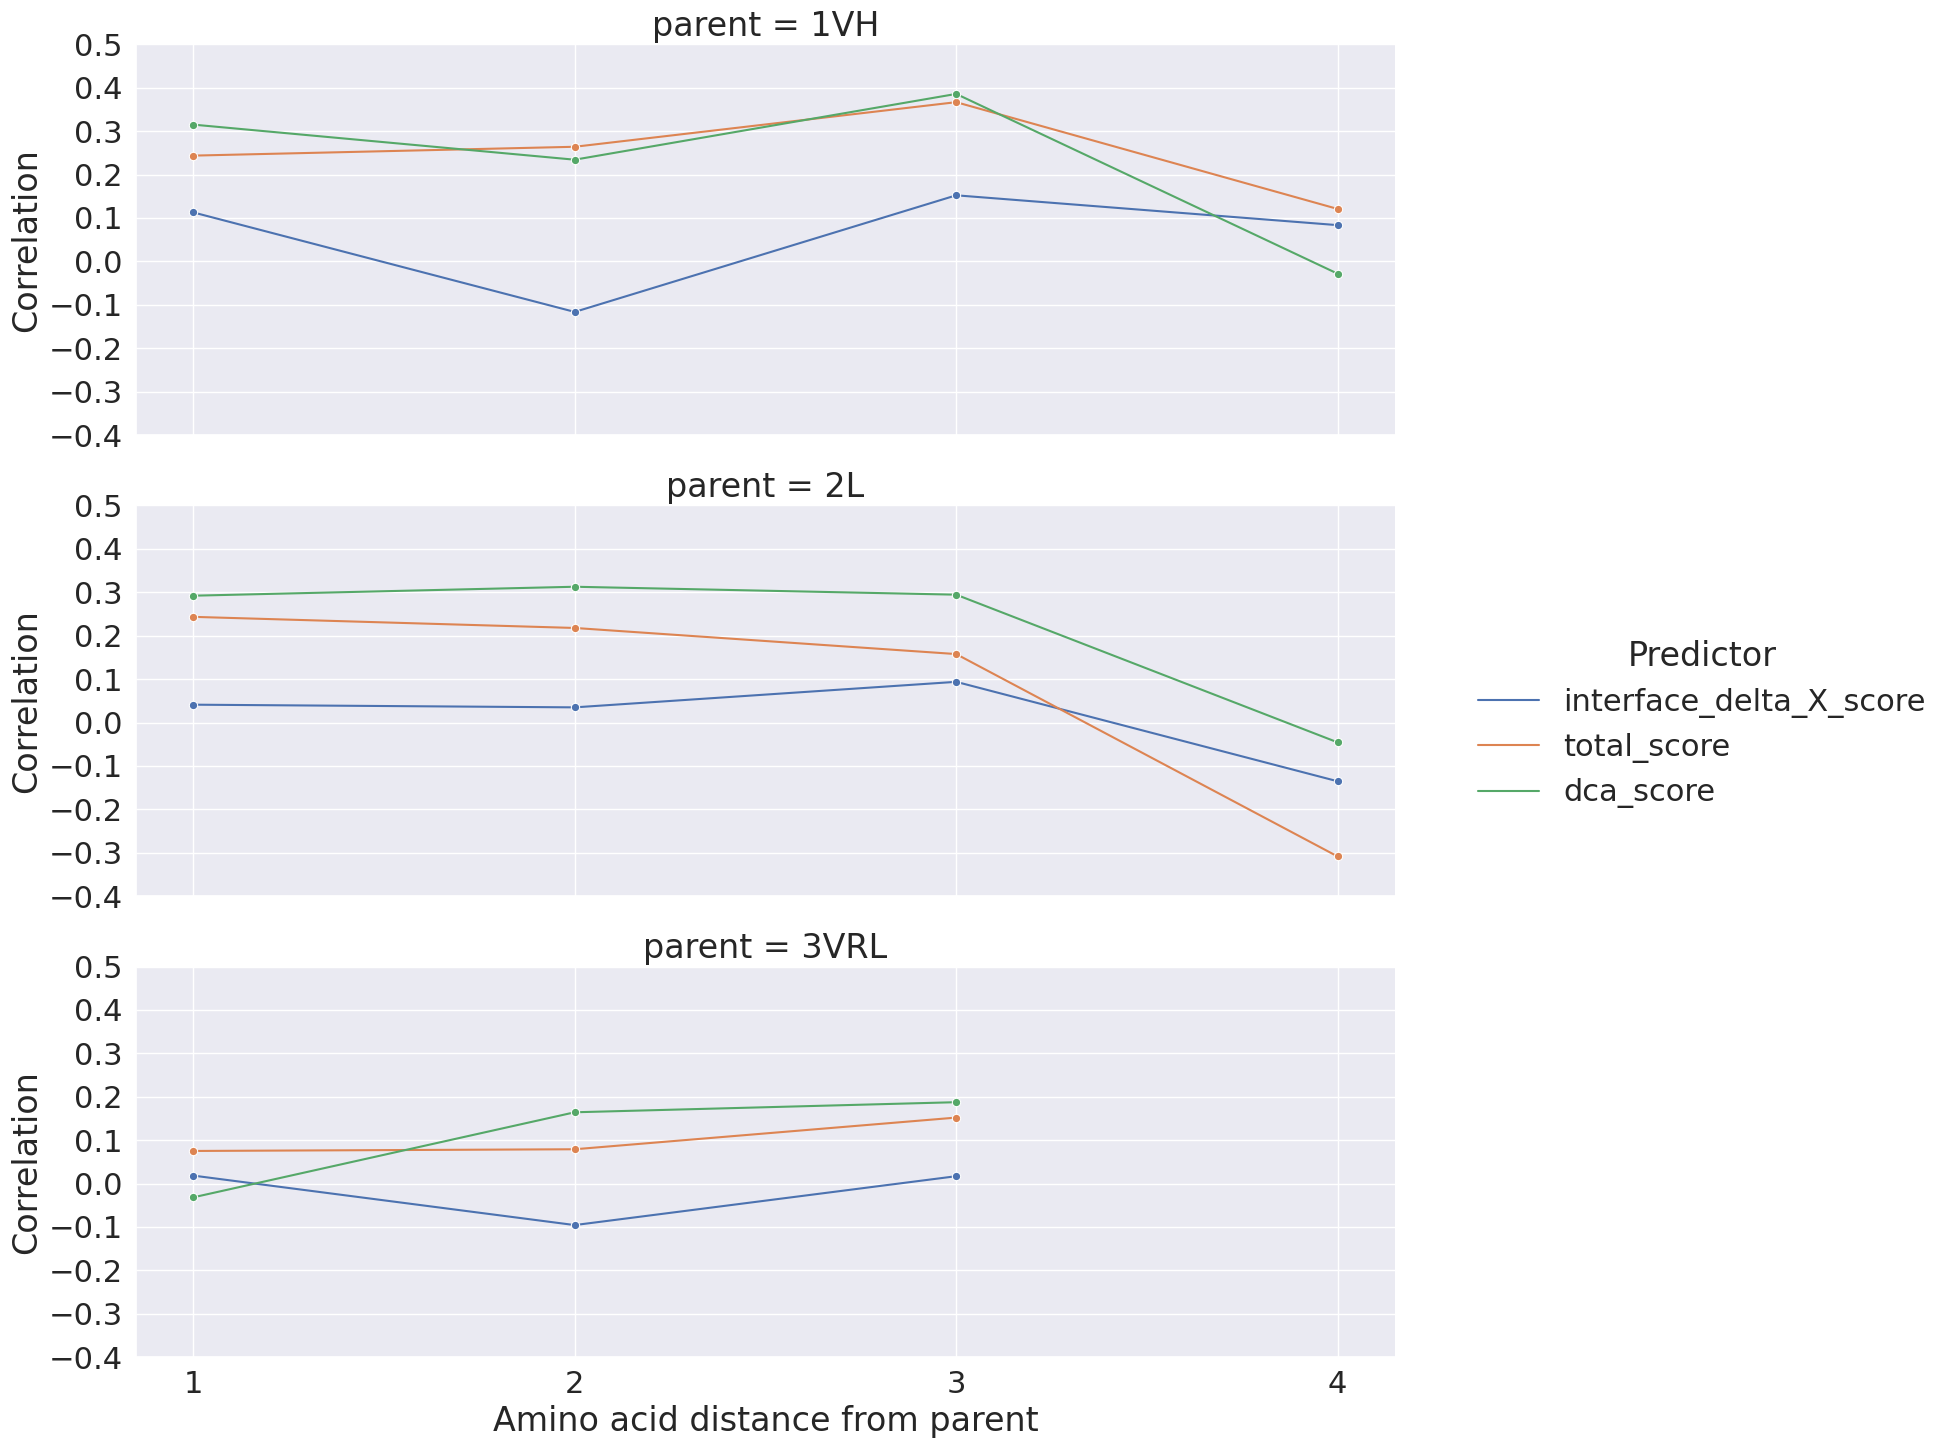

In [17]:
sns.set(font_scale=2)
g = sns.relplot(stats_to_plot_melt[~ stats_to_plot_melt.variable.str.endswith("_p")],
            x="aa_dist", y="value", row="parent", hue="variable", kind='line',
                aspect=3, marker='o')
_ = [ax.xaxis.set_major_locator(MaxNLocator(integer=True)) for ax in g.axes.flatten()]

_ = [ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1)) for ax in g.axes.flatten()]

g.set(ylabel="Correlation", ylim=(-0.4, 0.5), xlabel="Amino acid distance from parent")
g._legend.set_title("Predictor")
# replace labels
new_labels = ['interface_delta_X_score', 'total_score', 'dca_score']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    
g.fig.savefig("../output/ligand_docking_score_on_screening_data_mutation_adjusted.png", dpi=300)